In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import glob
import awkward as ak
import itertools
import yaml
import os
import sys
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
atl.ATLAS = "ColliderML"

sys.path.append("../")
import pyhepmc as hep
from pyhepmc.io import WriterAscii

In [4]:
# Configure paths and expected parameters
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

merged_path = Path("/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/merged_events.hepmc3")
assert merged_path.exists(), f"Merged file not found: {merged_path}"

mu = 200.0
print("Merged file:", merged_path)
print("Expected Poisson mu:", mu)


Merged file: /global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/merged_events.hepmc3
Expected Poisson mu: 200.0


In [5]:
# Use pyhepmc to read the merged events and estimate pileup multiplicity
import pyhepmc as hep

multiplicities = []
events_to_read = 128

with hep.open(str(merged_path)) as f:
    for i, evt in tqdm(enumerate(f)):
        # Count primary vertices as those with no incoming particles
        beam_particles = (evt.numpy.particles.status == 4).sum() / 2
        pileup_beam_particles = beam_particles - 1
        multiplicities.append(pileup_beam_particles)
        
        if i >= events_to_read:
            break

k = np.asarray(multiplicities, dtype=int) - 1
k = k[k >= 0]
print(f"Read {len(k)} events. k mean={k.mean():.2f}, std={k.std(ddof=1):.2f}")

# Save multiplicities for later use
output_dir = "."
multiplicities_file = output_dir / "pileup_multiplicities.npy"
np.save(multiplicities_file, k)
print(f"Saved multiplicities to: {multiplicities_file}")


128it [50:36, 23.72s/it]


Read 128 events. k mean=200.09, std=14.77


TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [6]:
# Save multiplicities for later use
output_dir = "."
multiplicities_file = Path(output_dir) / "pileup_multiplicities.npy"
np.save(multiplicities_file, k)
print(f"Saved multiplicities to: {multiplicities_file}")

Saved multiplicities to: pileup_multiplicities.npy


Empirical mean=200.09, var=218.24 (expected mean=var≈200.00)


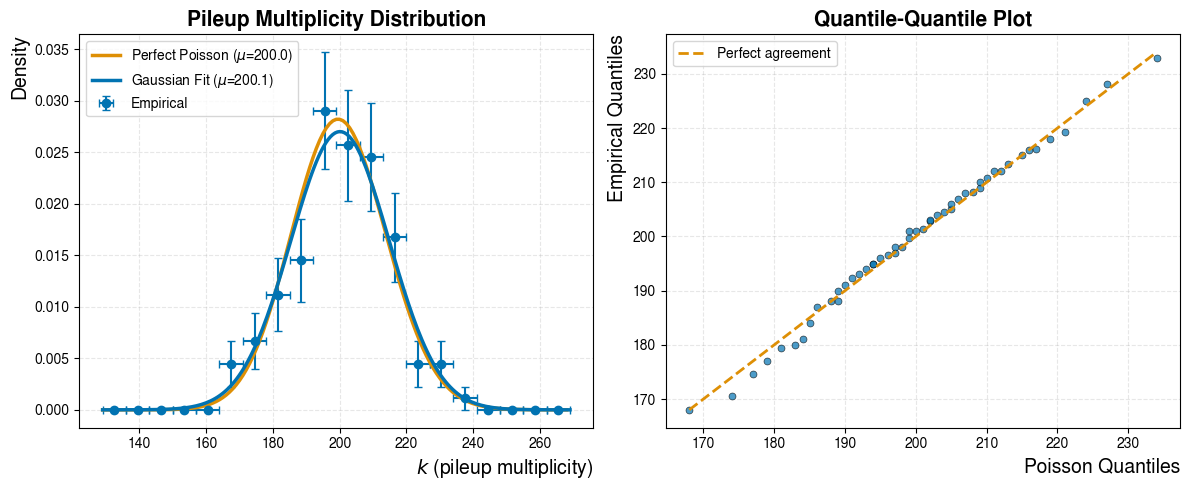

In [7]:
# Plot histogram and compare to Poisson(mu) and Gaussian fit
import scipy.stats as st
from scipy.optimize import curve_fit

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
if len(k):
    bin_width = 7
    bins = np.arange(max(1, int(mu - 5*np.sqrt(mu))), int(mu + 5*np.sqrt(mu)) + 2, bin_width)
    counts, bin_edges = np.histogram(k, bins=bins, density=True)
    raw_counts, _ = np.histogram(k, bins=bins, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = np.diff(bin_edges) / 2
    
    # Calculate uncertainty on density using Poisson statistics
    # For density: density = raw_count / (total_events * bin_width)
    # Uncertainty on raw_count is sqrt(raw_count) (Poisson)
    # Propagate to density
    total_events = len(k)
    counts_err = np.sqrt(raw_counts) / (total_events * bin_width)
    
    ax[0].errorbar(bin_centers, counts, xerr=bin_widths, yerr=counts_err, fmt='o', 
                   color='#0173B2', label="Empirical", 
                   markersize=6, capsize=3, linewidth=1.5)
    
    x = np.arange(bins[0], bins[-1])
    ax[0].plot(x, st.poisson(mu).pmf(x), color='#DE8F05', 
               linewidth=2.5, label=f"Perfect Poisson ($\\mu$={mu:.1f})", 
               markersize=4, markerfacecolor='white', markeredgewidth=1.5)
    
    # Fit Gaussian to empirical data
    emp_mean = float(np.mean(k))
    emp_std = float(np.std(k, ddof=1))
    x_continuous = np.linspace(bins[0], bins[-1], 200)
    gaussian_fit = st.norm(emp_mean, emp_std).pdf(x_continuous)
    ax[0].plot(x_continuous, gaussian_fit, color='#0173B2', 
               linewidth=2.5, 
               label=f"Gaussian Fit ($\\mu$={emp_mean:.1f})")
    
    ax[0].legend(frameon=True, loc='best')
    ax[0].set_ylabel("Density", fontsize=14)
ax[0].set_xlabel("$k$ (pileup multiplicity)", fontsize=14)
ax[0].set_title("Pileup Multiplicity Distribution", fontsize=15, fontweight='bold')
ax[0].grid(True, alpha=0.3, linestyle='--')
atl.set_xlabel(ax[0], "$k$ (pileup multiplicity)")
atl.set_ylabel(ax[0], "Density")

emp_mean = float(np.mean(k)) if len(k) else float('nan')
emp_var = float(np.var(k, ddof=1)) if len(k) > 1 else float('nan')
print(f"Empirical mean={emp_mean:.2f}, var={emp_var:.2f} (expected mean=var≈{mu:.2f})")

if len(k) >= 10:
    empirical = np.sort(k)
    quantiles = np.linspace(0.01, 0.99, 50)
    q_emp = np.quantile(empirical, quantiles)
    q_pois = st.poisson(mu).ppf(quantiles)
    ax[1].plot(q_pois, q_emp, 'o', ms=5, color='#0173B2', 
               alpha=0.7, markeredgecolor='black', markeredgewidth=0.5)
    ax[1].plot([q_pois.min(), q_pois.max()], [q_pois.min(), q_pois.max()], 
               color='#DE8F05', linestyle='--', linewidth=2, 
               label='Perfect agreement')
    ax[1].set_title("Quantile-Quantile Plot", fontsize=15, fontweight='bold')
    ax[1].legend(frameon=True, loc='best')
    ax[1].grid(True, alpha=0.3, linestyle='--')
ax[1].set_xlabel("Poisson Quantiles", fontsize=14)
ax[1].set_ylabel("Empirical Quantiles", fontsize=14)
atl.set_xlabel(ax[1], "Poisson Quantiles")
atl.set_ylabel(ax[1], "Empirical Quantiles")

plt.tight_layout()
plt.show()

# Save each subplot as separate PDF
fig_left, ax_left = plt.subplots(1, 1, figsize=(6, 5))
if len(k):
    ax_left.errorbar(bin_centers, counts, xerr=bin_widths, yerr=counts_err, fmt='o', 
                     color='#0173B2', label="Empirical", 
                     markersize=6, capsize=3, linewidth=1.5)
    ax_left.plot(x, st.poisson(mu).pmf(x), color='#DE8F05', 
                 linewidth=2.5, label=f"Perfect Poisson ($\\mu$={mu:.1f})", 
                 markersize=4, markerfacecolor='white', markeredgewidth=1.5)
    ax_left.plot(x_continuous, gaussian_fit, color='#0173B2', 
                 linewidth=2.5, 
                 label=f"Gaussian Fit ($\\mu$={emp_mean:.1f})")
    ax_left.legend(frameon=True, loc='best')
ax_left.set_xlabel("$k$ (pileup multiplicity)", fontsize=14)
ax_left.set_ylabel("Density", fontsize=14)
ax_left.set_title("Pileup Multiplicity Distribution", fontsize=15, fontweight='bold')
ax_left.grid(True, alpha=0.3, linestyle='--')
atl.set_xlabel(ax_left, "$k$ (pileup multiplicity)")
atl.set_ylabel(ax_left, "Density")
plt.tight_layout()
fig_left.savefig("pileup_distribution.pdf", dpi=300, format='pdf')
plt.close(fig_left)

if len(k) >= 10:
    fig_right, ax_right = plt.subplots(1, 1, figsize=(6, 5))
    ax_right.plot(q_pois, q_emp, 'o', ms=5, color='#0173B2', 
                  alpha=0.7, markeredgecolor='black', markeredgewidth=0.5)
    ax_right.plot([q_pois.min(), q_pois.max()], [q_pois.min(), q_pois.max()], 
                  color='#DE8F05', linestyle='--', linewidth=2, 
                  label='Perfect agreement')
    ax_right.set_xlabel("Poisson Quantiles", fontsize=14)
    ax_right.set_ylabel("Empirical Quantiles", fontsize=14)
    ax_right.set_title("Quantile-Quantile Plot", fontsize=15, fontweight='bold')
    ax_right.legend(frameon=True, loc='best')
    ax_right.grid(True, alpha=0.3, linestyle='--')
    atl.set_xlabel(ax_right, "Poisson Quantiles")
    atl.set_ylabel(ax_right, "Empirical Quantiles")
    plt.tight_layout()
    fig_right.savefig("pileup_qq_plot.pdf", dpi=300, format='pdf')
    plt.close(fig_right)
